#Leer archivos



In [15]:
# Read remote file
import pandas as pd
db = pd.read_csv("https://geographicdata.science/book/_downloads/7fb86b605af15b3c9cbd9bfcbead23e9/tokyo_clean.csv")
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10000 non-null  object 
 1   longitude             10000 non-null  float64
 2   latitude              10000 non-null  float64
 3   date_taken            10000 non-null  object 
 4   photo/video_page_url  10000 non-null  object 
 5   x                     10000 non-null  float64
 6   y                     10000 non-null  float64
dtypes: float64(4), object(3)
memory usage: 547.0+ KB


In [16]:
#Visualizar los datos, graficar

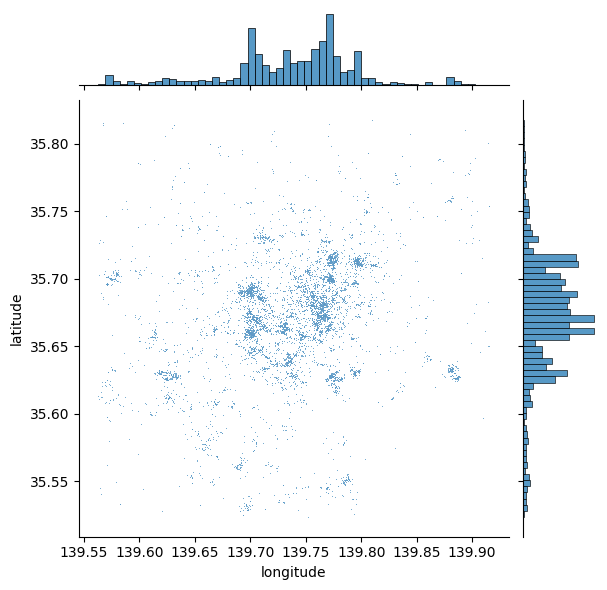

In [17]:
# Generar gráfico de dispersión
import seaborn as sbn
sbn.jointplot(x='longitude', y='latitude', data=db, s=0.5);

#Importar un shape de áreas y graficarlo

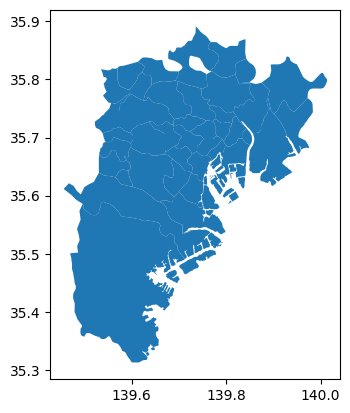

In [18]:
import geopandas as gpd
areas = gpd.read_file("https://darribas.org/gds_course/content/data/tokyo_admin_boundaries.geojson")
areas.plot();

In [19]:
!pip install contextily

#Superponer áreas y puntos

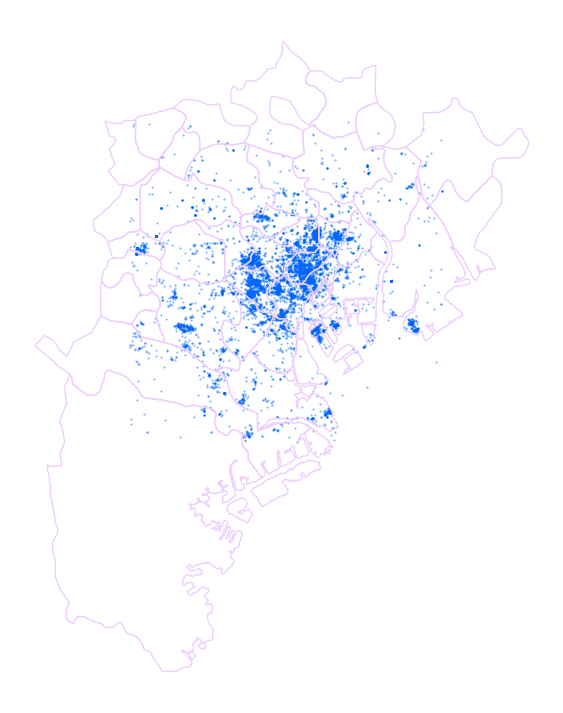

In [20]:
# Graficar los puntos para que sean pequeños y con transparencia, aquí defino que me grafiquen con long y lat
ax = db.plot.scatter("longitude","latitude",s=0.25,c="xkcd:bright blue",alpha=0.5,figsize=(9, 9))

# Añadir la capa de áreas o límites
areas.plot(ax=ax,facecolor="none",edgecolor="xkcd:pale lavender")

# Quitar ejes
ax.set_axis_off()

#Graficar una malla de hexagonos

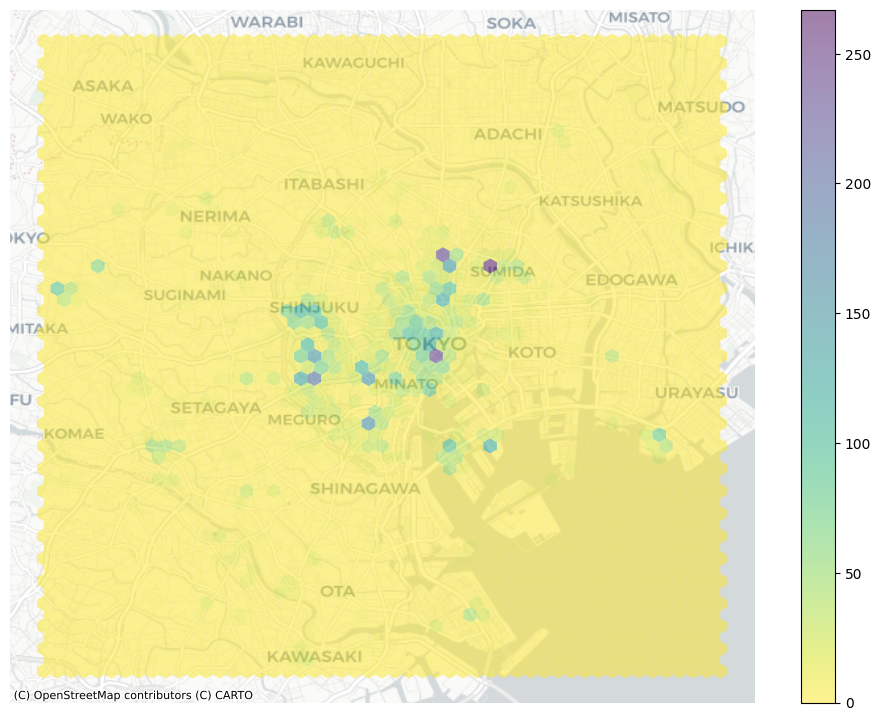

In [21]:
import matplotlib.pyplot as plt
#Contextily es la libreria para basemap
import contextily as ctx

# Configurar figura y ejes
f, ax = plt.subplots(1, figsize=(12, 9))

# Crear y añadir una malla de 50 hexagonos en cada dimensión, sin bordes, trnaparencia media , y definir colores de representación viridis
hb = ax.hexbin(
    db['x'],
    db['y'],
    gridsize=50,
    linewidths=0,
    alpha=0.5,
    cmap='viridis_r'
)
# Add basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)
# Add colorbar
plt.colorbar(hb)
# Remove axes
ax.set_axis_off()

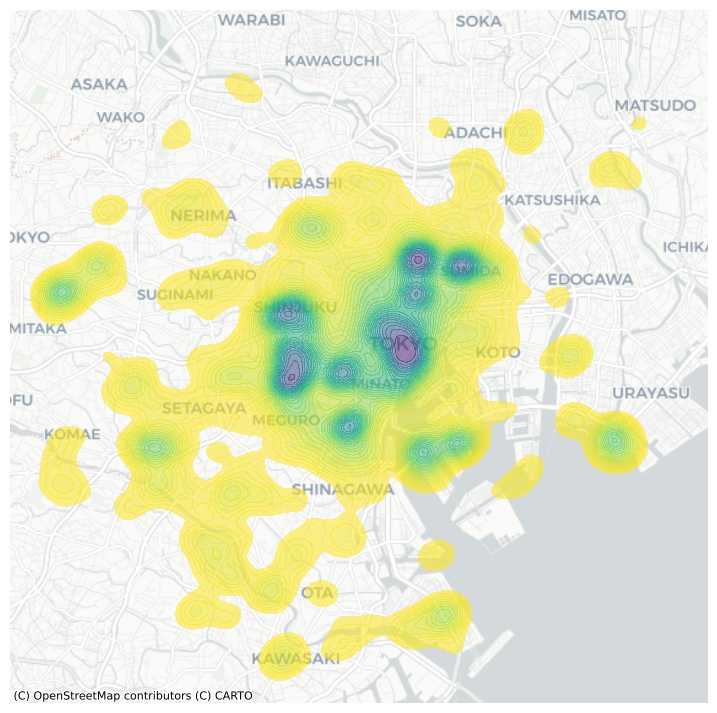

In [25]:
# Set up figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
sbn.kdeplot(x=db['x'],y=db['y'],n_levels=30,fill=True,alpha=0.55,cmap='viridis_r',
    bw_adjust=0.5)
# Add basemap
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)
# Remove axes
ax.set_axis_off();